# Ambient Temperature vs PD -- Laser Step-Down Run (2026-07-05 to 07-09)

Lines the ambient-temperature record (`ambient_temperature.ipynb`, true local time)
up against the PD trace (`laser_stepdown_settling.ipynb`, cymac GPS time) for the
same run, so the two can be compared on one clock.

**Clock offset:** cymac's GPS clock runs fast by an amount that has NOT been
constant across sessions: +5836 s (measured 2026-06-03), +3072 s (measured
**2026-07-09** -- the last day of this exact run), +4261 s (measured 2026-07-20,
a different session -- see `laser_calibration/pd_calibration.ipynb`). Because the
07-09 measurement falls inside this run, **+3072 s is the offset used here**, but
it is an anchor, not a verified value for the whole run: the three measurements
aren't a smooth monotonic drift (5836 -> 3072 -> 4261), so there's no safe way to
interpolate a better number for 07-05 specifically. Long (multi-hour) steps are
insensitive to an error of this size; several short sub-steps (40-70 min) are not
-- their per-step numbers below should be read with that caveat.

In [1]:
import csv
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

TEMP_CSV  = '/Users/mollywatts/Desktop/VSCode/decay_sail/analysis/ambient_temperature_20260705_0000_20260710_0000.csv'
STEPS_CSV = '/Users/mollywatts/Desktop/VSCode/decay_sail/analysis/laser_stepdown_steps.csv'
PD_FILES = [
    '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/PD/Y1_RDS-PD_IN1_DQ_1467323190_1467582390.h5',
    '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/PD/Y1_RDS-PD_IN1_DQ_1467582390_1467662710.h5',
]

GPS_UNIX_OFFSET = 315964800 - 18
TRUE_TIME_OFFSET_S = 3072   # cymac fast, measured 2026-07-09 (see markdown above)

def gps_to_dt(gps):
    return pd.Timestamp(gps + GPS_UNIX_OFFSET, unit='s', tz='UTC')

def gps_to_true_dt(gps):
    # cymac GPS -> best-estimate true UTC for this run (see markdown caveat)
    return gps_to_dt(gps - TRUE_TIME_OFFSET_S)

## 1. Load Both Series

In [2]:
# Ambient temperature (already true local time -> UTC)
temp_df = pd.read_csv(TEMP_CSV, parse_dates=['time'])
temp_df['time_utc'] = pd.to_datetime(temp_df['time'], utc=True)
temp_df = temp_df.sort_values('time_utc').reset_index(drop=True)
print(f"Temperature: {len(temp_df)} points  {temp_df['time_utc'].iloc[0]} -> {temp_df['time_utc'].iloc[-1]}")

# PD, 1 Hz strided (cymac GPS time)
def load_strided_multi(files, stride):
    t_list, y_list = [], []
    for path in files:
        with h5py.File(path, 'r') as f:
            fs   = float(f.attrs['sample_rate'])
            segs = f['segments/gps_start'][:].astype(np.float64)
            idxs = f['segments/index_start'][:].astype(np.int64)
            lens = f['segments/length'][:].astype(np.int64)
            dset = f['data']
            for gps0, ix, n in zip(segs, idxs, lens):
                y_seg = dset[ix: ix + n: stride].astype(np.float32)
                t_seg = gps0 + np.arange(len(y_seg)) * stride / fs
                t_list.append(t_seg); y_list.append(y_seg)
    t = np.concatenate(t_list); y = np.concatenate(y_list)
    order = np.argsort(t)
    return t[order], y[order]

t_pd_gps, y_pd = load_strided_multi(PD_FILES, 1024)   # 1 Hz effective
t_pd_true_utc = np.array([gps_to_true_dt(t) for t in t_pd_gps])
print(f"PD: {len(y_pd):,} points  {t_pd_true_utc[0]} -> {t_pd_true_utc[-1]}  (true-UTC estimate)")

Temperature: 720 points  2026-07-05 04:10:00+00:00 -> 2026-07-10 04:00:00+00:00
PD: 339,520 points  2026-07-05 20:55:00+00:00 -> 2026-07-09 19:13:39+00:00  (true-UTC estimate)


## 2. Trim to the Overlapping Window
Cut both series down to where they actually overlap -- the temperature record runs
a bit before/after the laser run, and the PD trace (in true-UTC estimate) may not
align exactly with the temperature record's start/end.

In [3]:
t_lo = max(temp_df['time_utc'].iloc[0], pd.Timestamp(t_pd_true_utc[0]))
t_hi = min(temp_df['time_utc'].iloc[-1], pd.Timestamp(t_pd_true_utc[-1]))
print(f"Overlap window: {t_lo} -> {t_hi}")

temp_m = (temp_df['time_utc'] >= t_lo) & (temp_df['time_utc'] <= t_hi)
temp_df = temp_df[temp_m].reset_index(drop=True)

pd_m = (t_pd_true_utc >= t_lo) & (t_pd_true_utc <= t_hi)
t_pd_true_utc = t_pd_true_utc[pd_m]
y_pd = y_pd[pd_m]
print(f"After trim: {len(temp_df)} temperature points, {len(y_pd):,} PD points")

Overlap window: 2026-07-05 20:55:00+00:00 -> 2026-07-09 19:13:39+00:00
After trim: 566 temperature points, 339,520 PD points


## 3. Overlay: PD (top) vs Temperature (bottom), Step Windows Shaded

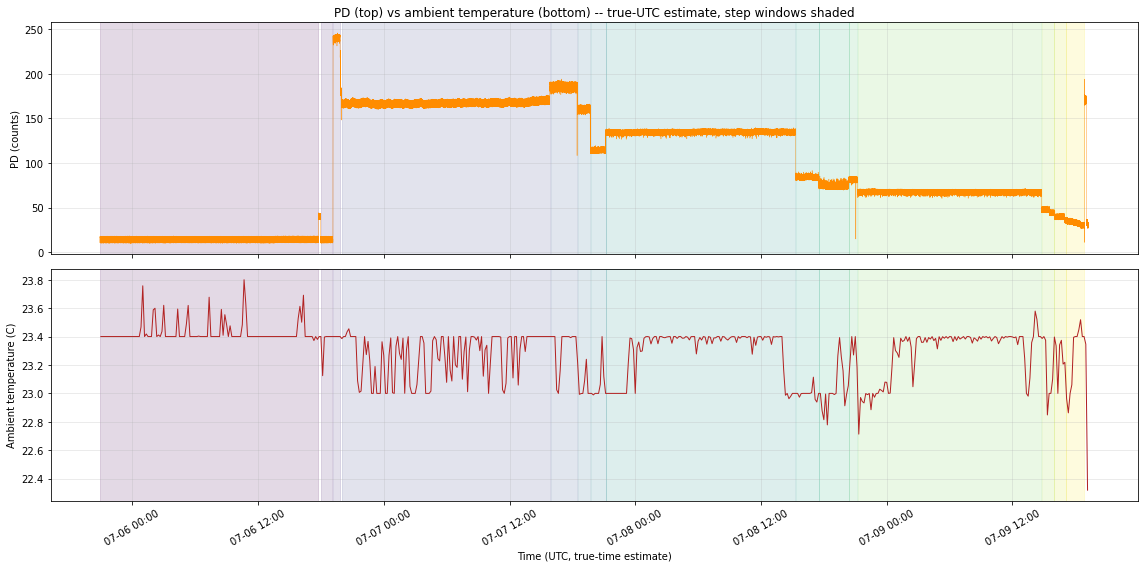

In [4]:
steps = []
with open(STEPS_CSV) as f:
    for row in csv.DictReader(f):
        steps.append(dict(step=int(row['step']), counts=row['counts'], power_mw=row['power_mw'],
                          t0=gps_to_true_dt(float(row['t_start_gps'])),
                          t1=gps_to_true_dt(float(row['t_end_gps']))))

def step_label(s):
    if s['counts']:
        return f"{s['counts']} cts ({float(s['power_mw']):.1f} mW)" if s['power_mw'] else f"{s['counts']} cts"
    return f"step {s['step']}"

colors = plt.cm.viridis(np.linspace(0, 1, len(steps)))

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(t_pd_true_utc, y_pd, linewidth=0.4, color='darkorange')
axes[0].set_ylabel('PD (counts)')
axes[0].set_title('PD (top) vs ambient temperature (bottom) -- true-UTC estimate, step windows shaded')
axes[0].grid(True, alpha=0.3)

axes[1].plot(temp_df['time_utc'], temp_df['temperature'], linewidth=1.0, color='firebrick')
axes[1].set_ylabel('Ambient temperature (C)')
axes[1].set_xlabel('Time (UTC, true-time estimate)')
axes[1].grid(True, alpha=0.3)

for ax in axes:
    for i, s in enumerate(steps):
        ax.axvspan(s['t0'], s['t1'], color=colors[i], alpha=0.15)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 4. Per-Step Temperature: Mean and Trend (Corrected Alignment)
Same comparison as `ambient_temperature.ipynb` Section 3, but now using the
clock-corrected step windows. Differences from the uncorrected version would be
most visible on the SHORT steps (2, 4, 5, 6, 9, 10, 12, 13, 14), which are close in
duration to the ~51-minute clock correction itself.

In [5]:
temp_t = temp_df['time_utc'].values.astype('datetime64[ns]').astype('int64') / 1e9
temp_v = temp_df['temperature'].values

print(f"{'step':>4} | {'level':>20} | {'dur (min)':>9} | {'mean C':>7} | {'trend (C over hold)':>19}")
for s in steps:
    t0u, t1u = s['t0'].timestamp(), s['t1'].timestamp()
    m = (temp_t >= t0u) & (temp_t <= t1u)
    dur_min = (t1u - t0u) / 60
    if m.sum() < 2:
        print(f"{s['step']:>4} | {step_label(s):>20} | {dur_min:>9.0f} | {'--':>7} | (no temp samples in window)")
        continue
    trend = temp_v[m][-1] - temp_v[m][0]
    print(f"{s['step']:>4} | {step_label(s):>20} | {dur_min:>9.0f} | {temp_v[m].mean():>7.2f} | {trend:>+19.3f}")

step |                level | dur (min) |  mean C | trend (C over hold)
   0 |               step 0 |      1250 |   23.43 |              -0.020
   1 |               step 1 |        65 |   23.36 |              -0.000
   2 |   1800 cts (12.5 mW) |        40 |   23.40 |              +0.000
   3 |   1600 cts (10.3 mW) |      1190 |   23.27 |              +0.014
   4 |    1550 cts (9.9 mW) |       150 |   23.33 |              +0.000
   5 |    1500 cts (9.2 mW) |        70 |   23.07 |              -0.219
   6 |    1400 cts (8.0 mW) |        85 |   23.06 |              +0.000
   7 |    1300 cts (6.7 mW) |      1080 |   23.31 |              +0.000
   8 |    1200 cts (5.4 mW) |       130 |   23.00 |              +0.000
   9 |               step 9 |       175 |   23.03 |              +0.054
  10 |              step 10 |        45 |   23.30 |              -0.044
  11 |    1000 cts (3.0 mW) |      1050 |   23.29 |              +0.687
  12 |              step 12 |        70 |   23.19 |             